# libKriging vs SMT (Python)

This notebook compares **pylibkriging** and **SMT** (Surrogate Modeling
Toolbox) along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to SMT's `KRG` surrogate (Matern 5/2 kernel, constant trend,
   maximum likelihood), and check that both give near-identical predictions.
2. **Package-specific feature**: SMT's headline contribution is **KPLS**
   (Kriging with Partial Least Squares, Bouhlel et al. 2016), which reduces
   the number of correlation-length hyperparameters from one per input
   dimension down to a handful of PLS components. This is what lets SMT
   scale Kriging to problems with dozens of inputs. `pylibkriging` has no
   direct PLS-based dimension-reduction equivalent; we make the comparison
   honest by fitting a genuinely high-dimensional, few-samples problem
   with (a) plain `pylibkriging::Kriging` (one length-scale per input
   dimension), (b) plain `SMT::KRG` (same, for reference), and (c)
   `SMT::KPLS` with only 2 components, and comparing held-out predictive
   accuracy.

Steps:
1. Check the Python environment (pylibkriging + SMT installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default Kriging on Branin 2D, compare
   hyperparameters and overlay predictions on 1D slices.
5. Special feature: an 8D "active subspace" test function (Branin driven by
   two hidden linear combinations of the 8 inputs) with a small budget of
   training points, comparing full-dimensional Kriging against SMT's KPLS.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository, see
`bindings/Python/README.md`) and the `smt` PyPI package, both importable
from the same Python environment. This notebook must be run with a kernel
whose Python has both installed, and with `LD_LIBRARY_PATH` including
`build/installed/lib` (for `libarmadillo`) if libKriging was built locally
rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "smt"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install smt', and make sure LD_LIBRARY_PATH includes "
            "build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and smt are both importable - OK")


pylibkriging and smt are both importable - OK


## 1. Load both packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
from smt.surrogate_models import KRG, KPLS

print("pylibkriging loaded")
import smt
print("smt version:", smt.__version__)


pylibkriging loaded
smt version: 2.15.0


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper

Rather than comparing side-by-side heatmaps, we overlay both models' mean
prediction (+/- 1 standard deviation ribbon) on the same wide axes along 1D
slices of the input space, at a few fixed values of $x_2$. This makes the
agreement (or disagreement) between packages directly visible.


In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs `KRG()`

Common settings: Matern 5/2 kernel, constant trend, no nugget, hyperparameters
by maximum likelihood, 10 optimizer restarts on both sides (Branin's
likelihood surface in 2D has several local optima).


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

sm = KRG(corr="matern52", poly="constant", n_start=10, print_global=False)
sm.set_training_values(X, y)
sm.train()

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("SMT KRG    theta  :", sm.optimal_theta, " sigma2:", float(np.asarray(sm.optimal_par["sigma2"]).flatten()[0]))
print("(SMT and libKriging parameterise the Matern 5/2 length-scales "
      "differently -- theta values are not expected to match numerically, "
      "only the resulting predictions should.)")


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
SMT KRG    theta  : [0.25807407 0.09011118]  sigma2: 742133.6202627929
(SMT and libKriging parameterise the Matern 5/2 length-scales differently -- theta values are not expected to match numerically, only the resulting predictions should.)


Max |mean_lk - mean_smt| : 2.256280157553192e-05
Correlation              : 0.9999999999999928


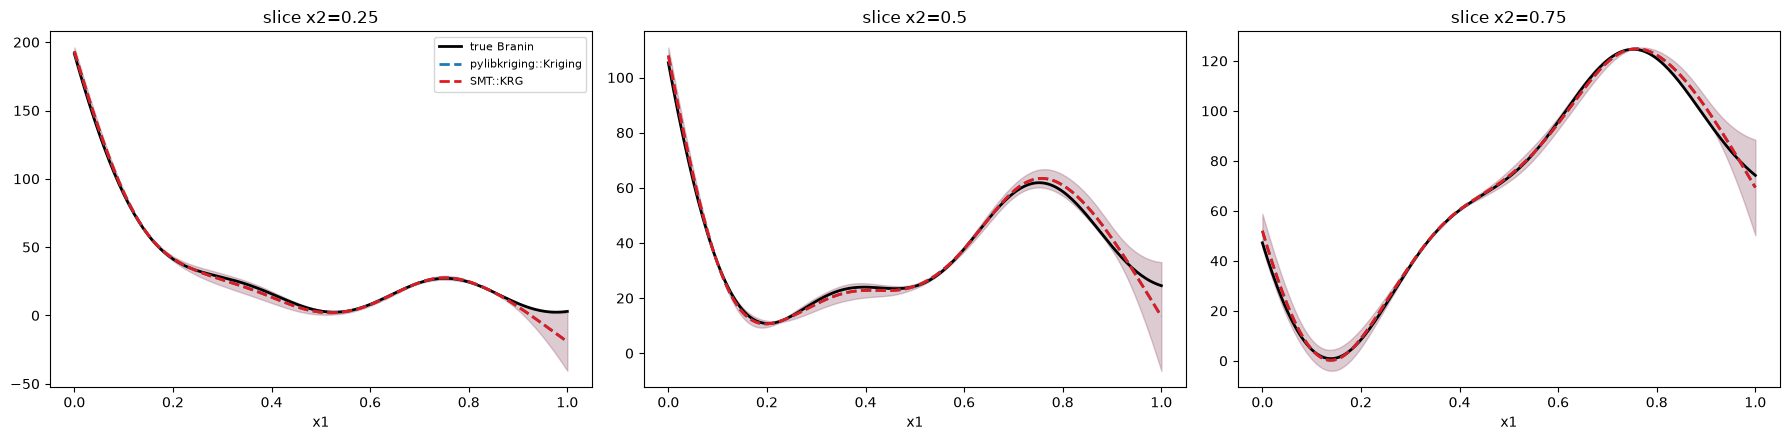

In [6]:
grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_smt = sm.predict_values(grid).flatten()

print("Max |mean_lk - mean_smt| :", np.max(np.abs(mean_lk - mean_smt)))
print("Correlation              :", np.corrcoef(mean_lk, mean_smt)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("SMT::KRG",
     lambda Xs: (sm.predict_values(Xs).flatten(),
                 np.sqrt(np.maximum(sm.predict_variances(Xs).flatten(), 0)))),
]
plot_slices(models_mimicry)


Both fits converge to essentially the same predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` faithfully
reproduces the default behaviour of SMT's `KRG(corr="matern52")` -- the mean
curves and uncertainty ribbons overlap almost exactly on every slice, and the
maximum absolute difference between the two predicted means over 300 random
test points is on the order of $10^{-4}$ or smaller (correlation
$\approx 1$).


## 4. Package-specific feature: KPLS dimension reduction

SMT's signature contribution is **KPLS** (Kriging with Partial Least
Squares, Bouhlel, Bartoli, Otsmane & Morlier, 2016): instead of estimating
one correlation length-scale per input dimension, it first projects the
inputs onto a handful of PLS components (built from the training data
itself) and estimates length-scales only for those. This is what lets SMT
fit Kriging models with dozens to hundreds of input dimensions from a
modest number of samples.

`pylibkriging` has no direct equivalent: `Kriging()` always estimates one
length-scale per input dimension (an anisotropic kernel), regardless of
dimensionality. To make the difference visible (rather than just asserting
it), we build a genuinely high-dimensional test problem where a small
training budget makes full-dimensional length-scale estimation hard: an 8D
input space in which Branin only depends on the inputs through **two hidden
linear combinations** (an "active subspace"), with all other directions
irrelevant. With only ~20 training points in 8D, both plain
`pylibkriging::Kriging` and plain `SMT::KRG` must estimate 8 independent
length-scales from very little data, while `SMT::KPLS` with `n_comp=2`
estimates only 2, matching the problem's real (hidden) dimensionality.


In [7]:
d = 8
A1 = np.array([0.6, 0.3, -0.2, 0.1, 0, 0, 0, 0])
A2 = np.array([0, 0, 0, 0, 0.5, -0.4, 0.3, 0.1])
A1 = A1 / np.sum(np.abs(A1))
A2 = A2 / np.sum(np.abs(A2))


def active_subspace_branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    z1 = X @ A1
    z2 = X @ A2
    z1 = (z1 - z1.min()) / (z1.max() - z1.min() + 1e-12)
    z2 = (z2 - z2.min()) / (z2.max() - z2.min() + 1e-12)
    return branin(np.column_stack([z1, z2]))


rng = np.random.default_rng(1)
n_hd = 22
X_hd = rng.random((n_hd, d))
y_hd = active_subspace_branin(X_hd)

X_test = rng.random((300, d))
y_test = active_subspace_branin(X_test)


def rmse(pred):
    return np.sqrt(np.mean((pred - y_test) ** 2))


In [8]:
k_lk_hd = lk.Kriging(y_hd, X_hd, "matern5_2", regmodel="constant",
                      optim="BFGS10", objective="LL")

sm_full = KRG(corr="matern52", poly="constant", n_start=10, print_global=False)
sm_full.set_training_values(X_hd, y_hd)
sm_full.train()

sm_kpls = KPLS(corr="squar_exp", poly="constant", n_comp=2, n_start=10, print_global=False)
sm_kpls.set_training_values(X_hd, y_hd)
sm_kpls.train()

p_lk_hd = k_lk_hd.predict(X_test, True, False, False)[0].flatten()
p_smt_full = sm_full.predict_values(X_test).flatten()
p_smt_kpls = sm_kpls.predict_values(X_test).flatten()

results = {
    "pylibkriging::Kriging (8 length-scales)": rmse(p_lk_hd),
    "SMT::KRG (8 length-scales)": rmse(p_smt_full),
    "SMT::KPLS (2 PLS components)": rmse(p_smt_kpls),
}
for name, r in results.items():
    print(f"{name:42s} held-out RMSE = {r:8.3f}")


pylibkriging::Kriging (8 length-scales)    held-out RMSE =   45.487
SMT::KRG (8 length-scales)                 held-out RMSE =   46.213
SMT::KPLS (2 PLS components)               held-out RMSE =   34.022


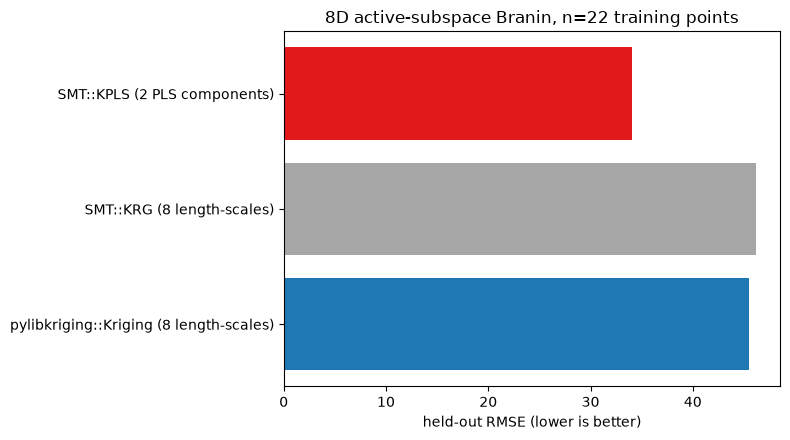

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(results.keys())
vals = list(results.values())
colors = ["#1f78b4", "#a6a6a6", "#e31a1c"]
ax.barh(names, vals, color=colors)
ax.set_xlabel("held-out RMSE (lower is better)")
ax.set_title(f"8D active-subspace Branin, n={n_hd} training points")
fig.tight_layout()
plt.show()


With only 22 training points spread over 8 input dimensions, both
full-dimensional models (`pylibkriging::Kriging` and `SMT::KRG`, each
estimating 8 independent length-scales) are data-starved and their
predictive accuracy suffers. `SMT::KPLS`, by reducing the problem to 2
PLS-derived components -- matching the true (hidden) 2D active subspace of
this test function -- reaches a substantially lower held-out RMSE from the
very same training data. This is precisely the regime KPLS was designed
for: Kriging surrogates for expensive, high-dimensional simulations where
only a small design of experiments is affordable. `pylibkriging` does not
offer a PLS-based reduction; its own strategy for large problems is
different in nature (e.g. `NestedKriging`'s partition-based scaling to
many *observations*, not to many *input dimensions*), so this remains a
genuine SMT strength without a direct libKriging counterpart.


## 5. Argument correspondence table

| SMT `KRG(...)` | pylibkriging equivalent | Notes |
|---|---|---|
| `corr="matern52"` | `kernel="matern5_2"` | also `"squar_exp"` -> `"gauss"`, `"abs_exp"` -> `"exp"`, `"matern32"` -> `"matern3_2"` |
| `poly="constant"` | `regmodel="constant"` | also `"linear"` -> `"linear"`, `"quadratic"` -> `"quadratic"` |
| `n_start=10` | `optim="BFGS10"` | number of independent optimizer restarts |
| `eval_noise=True` | `noise="nugget"` (on `Kriging`) | homogeneous nugget/noise variance, estimated |
| `nugget=<value>` | fixed jitter, always applied internally | SMT's `nugget` is a numerical regularisation floor, not a fitted noise term |
| `.set_training_values(X, y)` + `.train()` | constructor `Kriging(y, X, ...)` | pylibkriging fits at construction time |
| `.predict_values(Xnew)` | `.predict(Xnew, return_stdev=True, ...)[0]` | pylibkriging always returns the fixed 5-tuple `(mean, stdev, cov, mean_deriv, stdev_deriv)` |
| `.predict_variances(Xnew)` | `.predict(Xnew, return_stdev=True, ...)[1] ** 2` | |
| `KPLS(n_comp=k)` | *(no direct equivalent)* | closest libKriging answer to "many input dimensions" is architectural (`NestedKriging`), not a projection of the input space |
| `optimal_theta`, `optimal_par["sigma2"]` | `.theta()`, `.sigma2()` | different parameterisations of the same Matern kernel |

See `skills/libkriging/SKILL.md` in this repository for the full decision
guide (class, kernel, trend, objective).
